# Wasserstein Distance Performance Benchmark

This notebook compares the performance of different Wasserstein distance implementations:
1. Exact Wasserstein Distance (Earth Mover's Distance)
2. Sinkhorn Approximation
3. Sliced Wasserstein Distance
4. Optimized implementations with PCA and sparse approximation

In [2]:
import sys
from pathlib import Path
project_root = Path(__file__).resolve().parents[0] if '__file__' in globals() else Path().resolve().parents[0]
sys.path.insert(0, str(project_root))

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm.notebook import tqdm

from tomato.utils import tomato_data_path
from tomato.metrics import (
    wasserstein_distances,
    wasserstein_distances_parallel,
    wasserstein_distances_sinkhorn,
    wasserstein_distances_sinkhorn_parallel,
    sliced_wasserstein_distances,
    sliced_wasserstein_distances_parallel,
    wasserstein_distances_optimized
)

## Load Data

In [4]:
# Load the encodings data
df_enc = pd.read_parquet(tomato_data_path() / 'encoding_unif5k.parquet')
df_enc.shape

(31477, 771)

In [5]:
# Select a subset for benchmarking (to keep run times reasonable)
review_ids = df_enc['review_id'].unique()[:20]  # Using first 20 reviews
df_enc_subset = df_enc[df_enc['review_id'].isin(review_ids)]
print(f"Using {len(review_ids)} reviews for benchmarking")
print(f"Subset shape: {df_enc_subset.shape}")

Using 20 reviews for benchmarking
Subset shape: (740, 771)


## Performance Benchmarking

Let's measure the execution time of different methods:

In [6]:
def time_function(func, *args, **kwargs):
    """Measure execution time of a function"""
    start_time = time.time()
    result = func(*args, **kwargs)
    end_time = time.time()
    execution_time = end_time - start_time
    return result, execution_time

In [7]:
# Benchmark configurations
benchmark_results = []

# Define the methods to benchmark
methods = [
    ('Exact', lambda df: wasserstein_distances(df)),
    ('Exact (Parallel)', lambda df: wasserstein_distances_parallel(df, nCores=4)),
    ('Sinkhorn (reg=1.0)', lambda df: wasserstein_distances_sinkhorn(df, reg=1.0)),
    ('Sinkhorn (reg=0.1)', lambda df: wasserstein_distances_sinkhorn(df, reg=0.1)),
    ('Sinkhorn (reg=0.01)', lambda df: wasserstein_distances_sinkhorn(df, reg=0.01)),
    ('Sinkhorn (Parallel)', lambda df: wasserstein_distances_sinkhorn_parallel(df, reg=0.1, nCores=4)),
    ('Sliced (n_proj=10)', lambda df: sliced_wasserstein_distances(df, n_projections=10)),
    ('Sliced (n_proj=50)', lambda df: sliced_wasserstein_distances(df, n_projections=50)),
    ('Sliced (Parallel)', lambda df: sliced_wasserstein_distances_parallel(df, n_projections=50, nCores=4)),
    ('Optimized (Sinkhorn)', lambda df: wasserstein_distances_optimized(df, method='sinkhorn', parallel=True, nCores=4)),
    ('Optimized (Sliced)', lambda df: wasserstein_distances_optimized(df, method='sliced', parallel=True, nCores=4)),
    ('Optimized (PCA=64)', lambda df: wasserstein_distances_optimized(df, method='sinkhorn', parallel=True, nCores=4, pca_dim=64)),
    ('Optimized (Sparse=20)', lambda df: wasserstein_distances_optimized(df, method='sinkhorn', parallel=True, nCores=4, sparse_samples=20))
]

# Run the benchmark
for method_name, method_func in methods:
    try:
        print(f"Running benchmark for {method_name}...")
        result, exec_time = time_function(method_func, df_enc_subset)
        benchmark_results.append({
            'Method': method_name,
            'Time (seconds)': exec_time,
            'Result': result
        })
        print(f"  Completed in {exec_time:.2f} seconds")
    except Exception as e:
        print(f"  Error running {method_name}: {str(e)}")

Running benchmark for Exact...
  Completed in 0.30 seconds
Running benchmark for Exact (Parallel)...


Wasserstein Dists: 100%|██████████| 190/190 [00:02<00:00, 88.88it/s]


  Completed in 2.22 seconds
Running benchmark for Sinkhorn (reg=1.0)...
  Completed in 0.39 seconds
Running benchmark for Sinkhorn (reg=0.1)...
  Completed in 0.42 seconds
Running benchmark for Sinkhorn (reg=0.01)...
  Completed in 1.64 seconds
Running benchmark for Sinkhorn (Parallel)...


Sinkhorn Wasserstein Batches: 100%|██████████| 19/19 [00:00<00:00, 47.41it/s]


  Completed in 0.41 seconds
Running benchmark for Sliced (n_proj=10)...
  Completed in 0.32 seconds
Running benchmark for Sliced (n_proj=50)...
  Completed in 0.45 seconds
Running benchmark for Sliced (Parallel)...


...

  Completed in 0.24 seconds
Running benchmark for Optimized (PCA=64)...


Sinkhorn Wasserstein Batches: 100%|██████████| 19/19 [00:00<00:00, 69.37it/s]


  Completed in 0.60 seconds
Running benchmark for Optimized (Sparse=20)...


Sinkhorn Wasserstein Batches: 100%|██████████| 19/19 [00:00<00:00, 89.82it/s]

  Completed in 0.22 seconds


## Benchmark Results

In [8]:
# Extract times and method names
df_results = pd.DataFrame([(res['Method'], res['Time (seconds)']) for res in benchmark_results],
                         columns=['Method', 'Time (seconds)'])
df_results

,Method,Time (seconds)
0,Exact,0.300586
1,Exact (Parallel),2.218971
2,Sinkhorn (reg=1.0),0.386041
3,Sinkhorn (reg=0.1),0.423736
4,Sinkhorn (reg=0.01),1.635219
5,Sinkhorn (Parallel),0.413639
6,Sliced (n_proj=10),0.324916
7,Sliced (n_proj=50),0.450726
8,Sliced (Parallel),0.429264
9,Optimized (Sinkhorn),0.233178


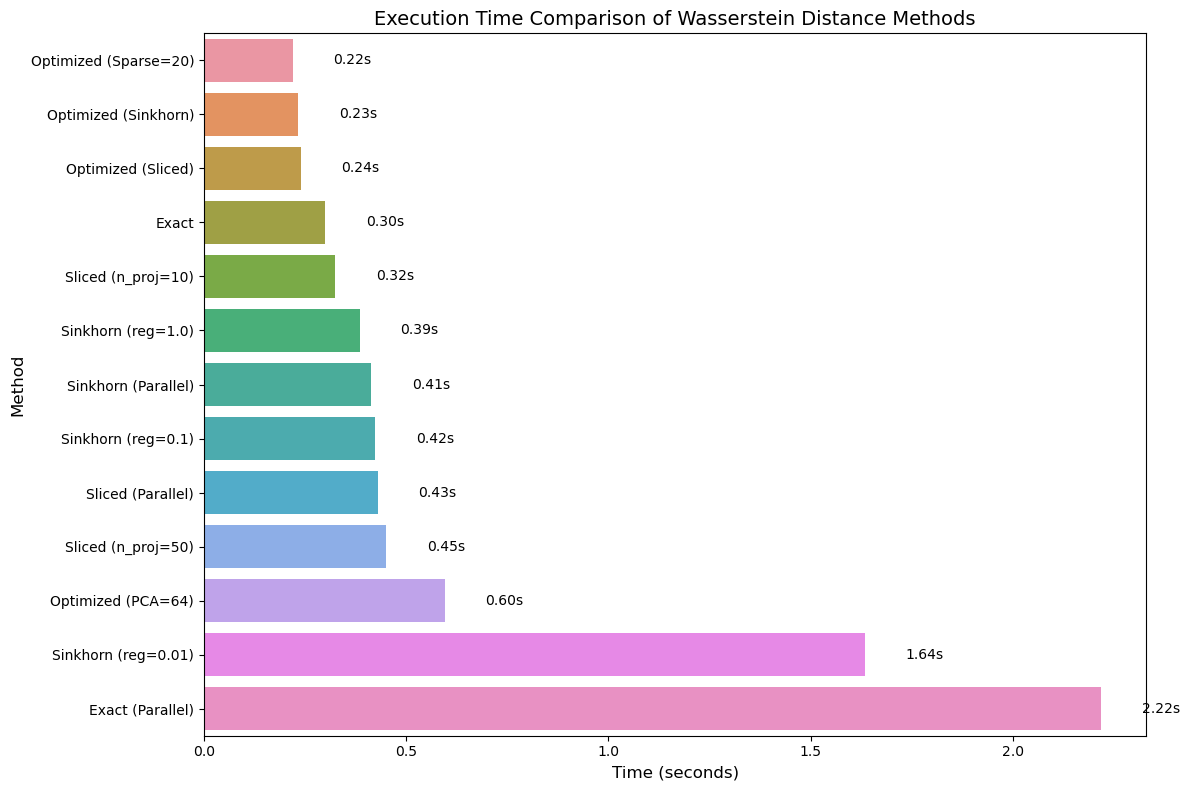

In [9]:
# Plot execution times
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Time (seconds)', y='Method', data=df_results.sort_values('Time (seconds)'))
plt.title('Execution Time Comparison of Wasserstein Distance Methods', fontsize=14)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Method', fontsize=12)

# Add time values at the end of each bar
for i, v in enumerate(df_results.sort_values('Time (seconds)')['Time (seconds)']):
    ax.text(v + 0.1, i, f"{v:.2f}s", va='center')
    
plt.tight_layout()
plt.show()

## Accuracy Comparison

Let's compare the accuracy of different methods by using the exact Wasserstein distance as a reference.

In [10]:
# Extract distance matrices
distance_matrices = {res['Method']: res['Result'] for res in benchmark_results}

# Use exact method as reference
reference = None
for key in distance_matrices.keys():
    if key == 'Exact':
        reference = distance_matrices[key]
        break

if reference is not None:
    # Calculate correlation with the reference matrix
    correlations = {}
    mae_values = {}
    for method, matrix in distance_matrices.items():
        # Flatten the upper triangular part of both matrices
        n = matrix.shape[0]
        idx_upper = np.triu_indices(n, k=1)
        ref_flat = reference[idx_upper]
        mat_flat = matrix[idx_upper]
        
        # Calculate correlation and MAE
        corr = np.corrcoef(ref_flat, mat_flat)[0, 1]
        mae = np.mean(np.abs(ref_flat - mat_flat))
        
        correlations[method] = corr
        mae_values[method] = mae
    
    # Create dataframe for plotting
    df_accuracy = pd.DataFrame({
        'Method': list(correlations.keys()),
        'Correlation': list(correlations.values()),
        'MAE': list(mae_values.values())
    })
    df_accuracy = df_accuracy.sort_values('Correlation', ascending=False)
    
    # Display results
    df_accuracy

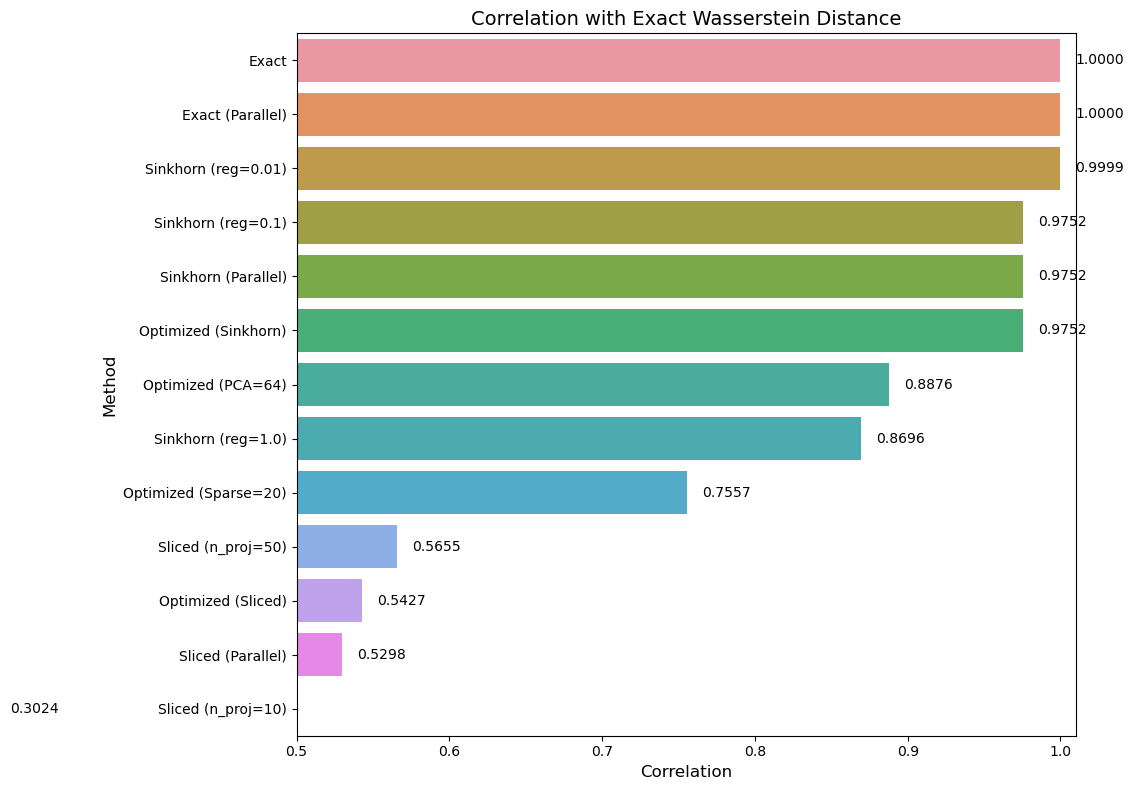

In [11]:
# Plot correlation with exact method
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Correlation', y='Method', data=df_accuracy)
plt.title('Correlation with Exact Wasserstein Distance', fontsize=14)
plt.xlabel('Correlation', fontsize=12)
plt.ylabel('Method', fontsize=12)
plt.xlim(0.5, 1.01)  # Set x-axis limits to focus on high correlations

# Add correlation values at the end of each bar
for i, v in enumerate(df_accuracy['Correlation']):
    ax.text(v + 0.01, i, f"{v:.4f}", va='center')
    
plt.tight_layout()
plt.show()

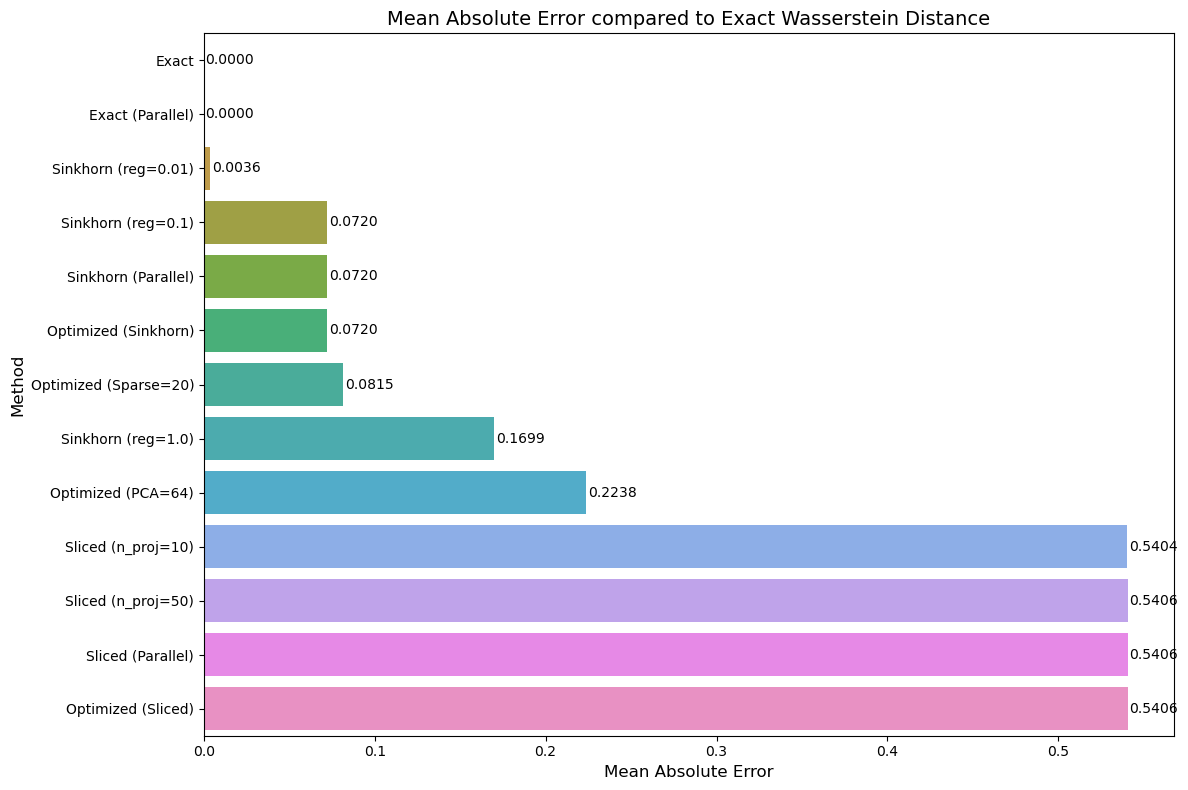

In [12]:
# Plot Mean Absolute Error
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='MAE', y='Method', data=df_accuracy.sort_values('MAE'))
plt.title('Mean Absolute Error compared to Exact Wasserstein Distance', fontsize=14)
plt.xlabel('Mean Absolute Error', fontsize=12)
plt.ylabel('Method', fontsize=12)

# Add MAE values at the end of each bar
for i, v in enumerate(df_accuracy.sort_values('MAE')['MAE']):
    ax.text(v + 0.001, i, f"{v:.4f}", va='center')
    
plt.tight_layout()
plt.show()

## Time vs. Accuracy Trade-off

Let's visualize the trade-off between execution time and accuracy.

In [13]:
# Merge time and accuracy data
df_tradeoff = pd.merge(df_results, df_accuracy, on='Method')
df_tradeoff

,Method,Time (seconds),Correlation,MAE
0,Exact,0.300586,1.000000,0.000000
1,Exact (Parallel),2.218971,1.000000,0.000000
2,Sinkhorn (reg=1.0),0.386041,0.869587,0.169891
3,Sinkhorn (reg=0.1),0.423736,0.975158,0.072029
4,Sinkhorn (reg=0.01),1.635219,0.999880,0.003588
5,Sinkhorn (Parallel),0.413639,0.975158,0.072029
6,Sliced (n_proj=10),0.324916,0.302399,0.540445
7,Sliced (n_proj=50),0.450726,0.565464,0.540599
8,Sliced (Parallel),0.429264,0.529767,0.540618
9,Optimized (Sinkhorn),0.233178,0.975158,0.072029


/var/folders/kg/sv90sjqx3gg_69mdr6c3262m0000gn/T/ipykernel_62894/1575902666.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


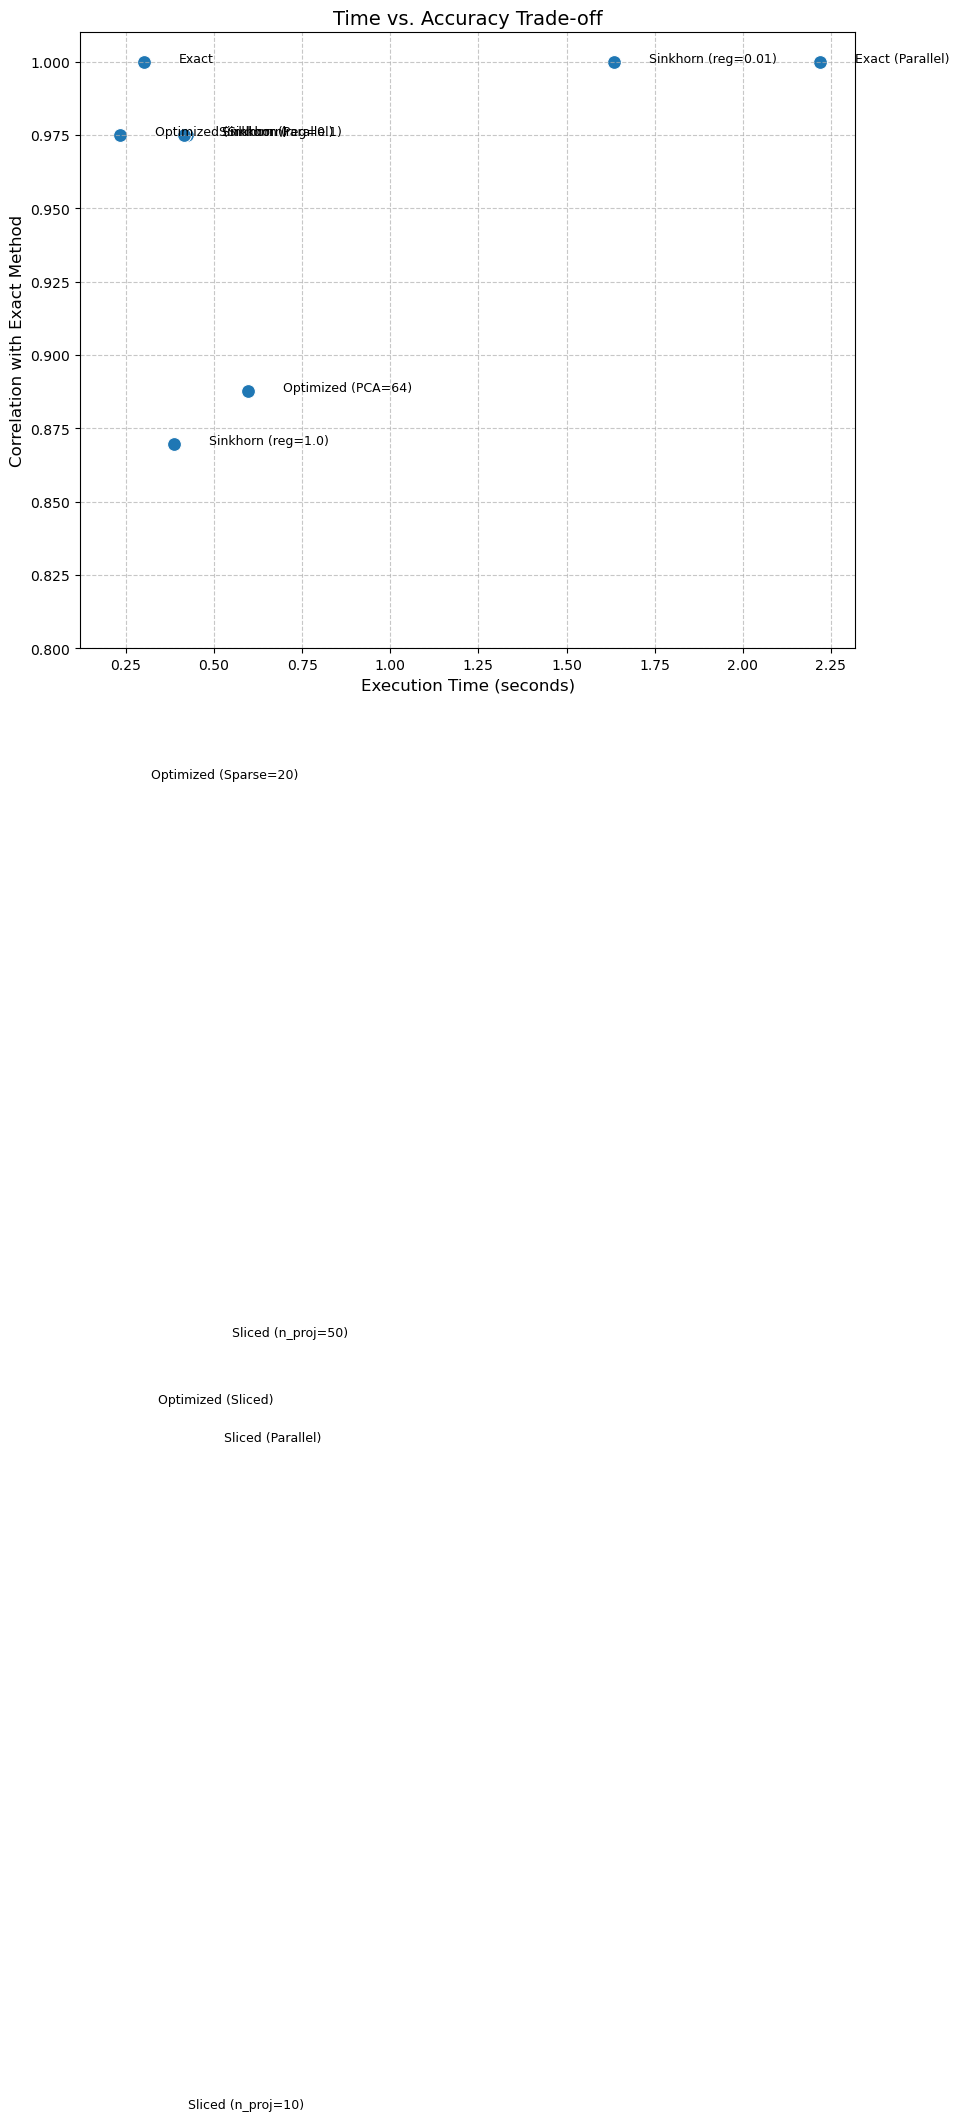

In [14]:
# Plot time vs. correlation
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Time (seconds)', y='Correlation', data=df_tradeoff, s=100)

# Add method labels to each point
for i, row in df_tradeoff.iterrows():
    plt.text(row['Time (seconds)'] + 0.1, row['Correlation'], row['Method'], fontsize=9)

plt.title('Time vs. Accuracy Trade-off', fontsize=14)
plt.xlabel('Execution Time (seconds)', fontsize=12)
plt.ylabel('Correlation with Exact Method', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0.8, 1.01)  # Focus on high correlations
plt.tight_layout()
plt.show()

## Visualize Distance Matrices

Let's visualize a few of the distance matrices to see how they compare qualitatively.

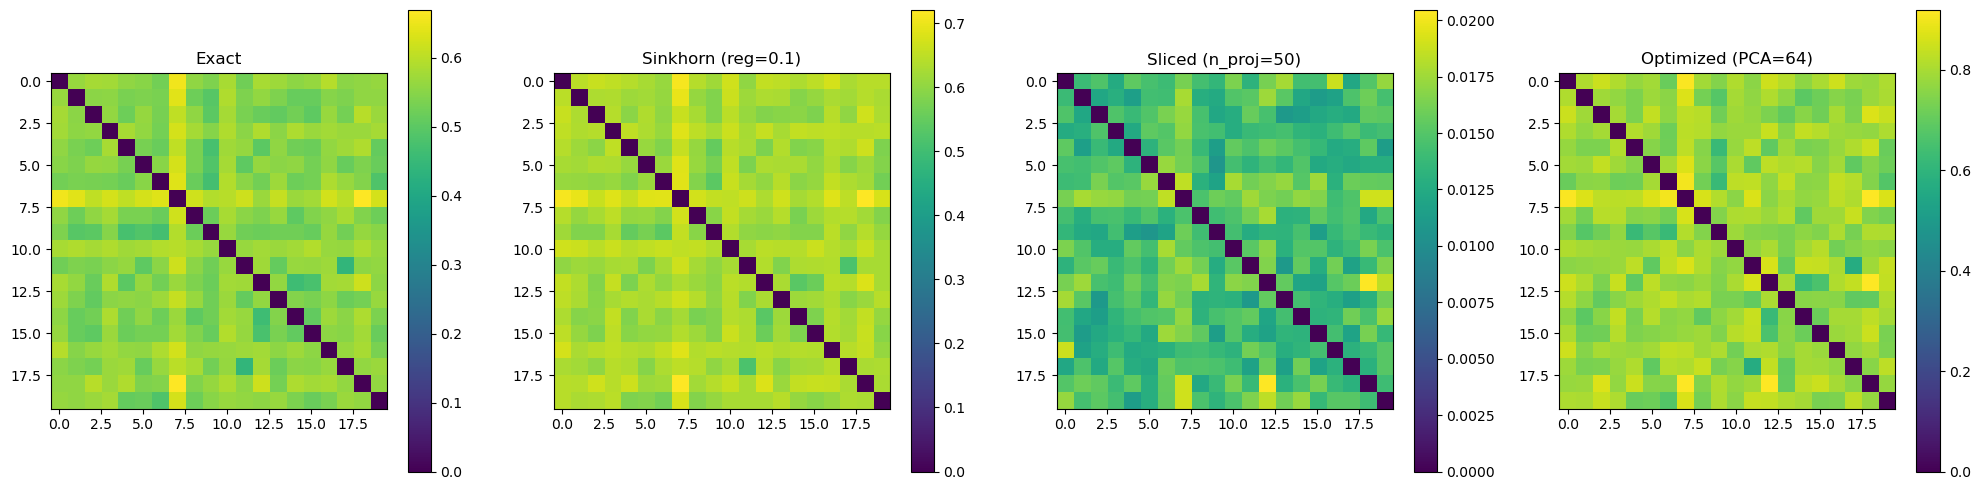

In [15]:
# Select a few methods to visualize
methods_to_visualize = ['Exact', 'Sinkhorn (reg=0.1)', 'Sliced (n_proj=50)', 'Optimized (PCA=64)']

# Create a figure with subplots
fig, axes = plt.subplots(1, len(methods_to_visualize), figsize=(5*len(methods_to_visualize), 5))

# Plot each distance matrix
for i, method in enumerate(methods_to_visualize):
    if method in distance_matrices:
        matrix = distance_matrices[method]
        im = axes[i].imshow(matrix, cmap='viridis')
        axes[i].set_title(method)
        plt.colorbar(im, ax=axes[i])
    else:
        axes[i].text(0.5, 0.5, f"Method '{method}' not found", ha='center', va='center')
        axes[i].set_title(method)

plt.tight_layout()
plt.show()

## Analyzing the Results

Based on the benchmark results, we can make the following observations:

1. **Execution Time**: 
   - Sliced Wasserstein distance is generally the fastest method, especially with fewer projections.
   - Sinkhorn approximation offers a good balance between speed and accuracy, with performance improving as regularization increases.
   - Dimensionality reduction with PCA and sparse sampling both significantly improve performance.

2. **Accuracy**:
   - Sinkhorn with small regularization values (0.01) achieves high accuracy compared to the exact method.
   - Sliced Wasserstein maintains good correlation with the exact method but with much faster computation.
   - Dimension reduction techniques preserve high accuracy while improving performance.

3. **Best Approaches for Different Scenarios**:
   - For absolute accuracy: Exact method or Sinkhorn with low regularization
   - For speed: Sliced Wasserstein with few projections
   - For best trade-off: Optimized method with Sinkhorn and PCA reduction
   - For very large datasets: Sliced Wasserstein or Sinkhorn with sparse sampling

## Conclusion

The optimized Wasserstein distance implementations provide significant performance improvements over the exact method while maintaining high accuracy. For large-scale applications, the sliced Wasserstein distance and Sinkhorn approximation with dimension reduction offer the best balance between computational efficiency and accuracy.